In [7]:
from dotenv import load_dotenv
import os
from langchain_core.messages import ToolMessage, BaseMessage
import importlib
from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    AnyMessage,
    BaseMessage, 
    AIMessage, 
    HumanMessage, 
    SystemMessage,
    ToolMessage,
    ToolCall
    )

In [28]:
load_dotenv()

llm = ChatOpenAI(model = "gpt-4o-mini")

In [ ]:
llm.invoke

Signature:
llm.invoke(
    input: 'LanguageModelInput',
    config: 'Optional[RunnableConfig]' = None,
    *,
    stop: 'Optional[list[str]]' = None,
    **kwargs: 'Any',
) -> 'BaseMessage'
Docstring:
Transform a single input into an output.

Args:
    input: The input to the Runnable.
    config: A config to use when invoking the Runnable.
       The config supports standard keys like 'tags', 'metadata' for tracing
       purposes, 'max_concurrency' for controlling how much work to do
       in parallel, and other keys. Please refer to the RunnableConfig
       for more details.

Returns:
    The output of the Runnable.
Source:   
    @override
    def invoke(
        self,
        input: LanguageModelInput,
        config: Optional[RunnableConfig] = None,
        *,
        stop: Optional[list[str]] = None,
        **kwargs: Any,
    ) -> BaseMessage:
        config = ensure_config(config)
        return cast(
            "ChatGeneration",
            self.generate_prompt(
          

In [ ]:
import run_agent_test as play
importlib.reload(play)

<module 'main' from '/Users/lars/Documents/dev/python/AiStagePlayGen/main.py'>

In [12]:
graph = play.graph

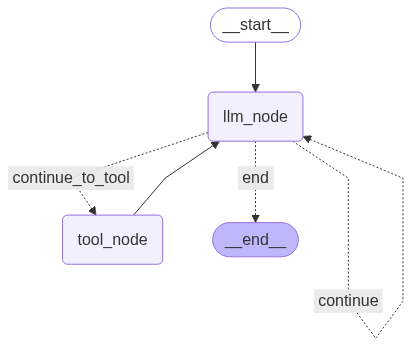

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
from agent_tools.characters import characters

luna = characters["Luna"]
print(str(luna))

Character(name='Luna', gender='F', age=16, disposition='Sassy', relationships={'Swedenborg': 'Aimicable'})


In [ ]:
from agent_tools.characters import roster, get_character_description, create_character

In [2]:
roster = roster

In [5]:
get_character_description.invoke('Luna')

"Character(name='Luna', gender='F', age=16, disposition='Sassy', relationships={'Swedenborg': 'Aimicable'})"

In [6]:
create_character.invoke({
     "character_name": "Sven Nord",
    "age" : 38,
    "gender" : 'M',
    "disposition" : "Inquisitve",
    "relationships_out" :  {"Luna": "Random person he met", "Swedenborg": "Suspects him being the culprit"},
    "relationships_in" :{ "Luna": "Random person she met", "Swedenborg": "Suspects him suspecting him being the culprit"},
    }
    )

'caracter Sven Nord created'

In [22]:
from enum import Enum

class ContextLength(Enum):
    short = 15


In [2]:
a = list(range(10))

In [ ]:
a[-10]


0

In [16]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)


# 1. Build a ToolCall object (name + args [+ optional id])
call = ToolCall(
    name="get_weather",           # the tool/function name
    args={"location": "Oslo"},    # arguments as a *dict*
    id="call-1"                   # optional; uuid4 auto-generated if omitted
)

# 2. Wrap it in an AIMessage
fake_ai = AIMessage(
    content="",        # must be empty when a tool is being invoked
    tool_calls=[call]  # list, because the model can call several tools
)


messages = [
    SystemMessage(content="You are a helpful assistant"),
    HumanMessage(content="Hello there!"), 
    fake_ai,
    ToolMessage(content="Weather is nice!", tool_call_id= "call-1"),
]

payload = llm._get_request_payload(messages)   # <-- inspect me
print(payload["messages"])          # final role/content objects
print({k: v for k, v in payload.items() if k != "messages"})


[{'content': 'You are a helpful assistant', 'role': 'system'}, {'content': 'Hello there!', 'role': 'user'}, {'content': None, 'role': 'assistant', 'tool_calls': [{'type': 'function', 'id': 'call-1', 'function': {'name': 'get_weather', 'arguments': '{"location": "Oslo"}'}}]}, {'content': 'Weather is nice!', 'role': 'tool', 'tool_call_id': 'call-1'}]
{'model': 'gpt-4o-mini', 'stream': False, 'temperature': 0.2}


In [ ]:
not messages[-2].tool_calls

False

In [29]:
simple_tool_message = ToolMessage(content="this is a tool message", tool_call_id="id")
llm._get_request_payload([simple_tool_message])

{'model': 'gpt-4o-mini',
 'stream': False,
 'temperature': 0.2,
 'messages': [{'content': 'this is a tool message',
   'role': 'tool',
   'tool_call_id': 'id'}]}

In [ ]:
llm.invoke(messages)

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 46, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_62a23a81ef', 'id': 'chatcmpl-Br9AyiZvOOd1dR0mqI4R1rmQ7tmBF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--edc19ccc-02b0-4d8a-aa86-e3321ef6de06-0', usage_metadata={'input_tokens': 46, 'output_tokens': 9, 'total_tokens': 55, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [13]:
import inspect
from langchain_core.messages.utils import trim_messages

In [20]:

import sqlite3

In [18]:
from langgraph.checkpoint.sqlite import SqliteSaver

write_config = {"configurable": {"thread_id": "1", "checkpoint_ns": ""}}
read_config = {"configurable": {"thread_id": "1"}}

with SqliteSaver.from_conn_string("checkpoints.sqlite") as checkpointer:
    checkpoint = {
        "v": 4,
        "ts": "2024-07-31T20:14:19.804150+00:00",
        "id": "1ef4f797-8335-6428-8001-8a1503f9b875",
        "channel_values": {
            "my_key": "meow",
            "node": "node"
        },
        "channel_versions": {
            "__start__": 2,
            "my_key": 3,
            "start:node": 3,
            "node": 3
        },
        "versions_seen": {
            "__input__": {},
            "__start__": {
                "__start__": 1
            },
            "node": {
                "start:node": 2
            }
        },
    }

    # store checkpoint
    checkpointer.put(write_config, checkpoint, {}, {})

    # load checkpoint
    checkpointer.get(read_config)

    # list checkpoints
    print(list(checkpointer.list(read_config)))

[CheckpointTuple(config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef4f797-8335-6428-8001-8a1503f9b875'}}, checkpoint={'v': 4, 'ts': '2024-07-31T20:14:19.804150+00:00', 'id': '1ef4f797-8335-6428-8001-8a1503f9b875', 'channel_values': {'my_key': 'meow', 'node': 'node'}, 'channel_versions': {'__start__': 2, 'my_key': 3, 'start:node': 3, 'node': 3}, 'versions_seen': {'__input__': {}, '__start__': {'__start__': 1}, 'node': {'start:node': 2}}}, metadata={'thread_id': '1'}, parent_config=None, pending_writes=[])]


In [ ]:
from run_agent_test import builder
# Correct usage with context manager

In [ ]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph


In [ ]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph


# At app startup: Reinitialize checkpointer and graph
checkpointer = SqliteSaver.from_conn_string("checkpoints.sqlite")
graph = builder.compile(checkpointer=checkpointer)  # Recompile your graph

# Assume you retrieve the thread_id from your app's storage (e.g., user DB)
thread_id = "user-session-123"  # Fetch this dynamically, e.g., from a user session
config = {"configurable": {"thread_id": thread_id}}

# Retrieve the latest saved state
state = graph.get_state(config)

AttributeError: '_GeneratorContextManager' object has no attribute 'get_tuple'

In [51]:
with SqliteSaver.from_conn_string("checkpoints.sqlite") as checkpinter:
    a = checkpinter.get(grap_config :={"configurable": {"thread_id": "1"}})

In [79]:
z = input()

In [52]:
graph = builder.compile(checkpointer= a)


In [ ]:
graph.get_state(grap_config)

AttributeError: 'dict' object has no attribute 'get_tuple'

In [61]:
conn = sqlite3.connect("checkpoints.sqlite")
checkpointer = SqliteSaver(conn)

In [ ]:
graph = builder.compile(checkpointer= checkpointer)

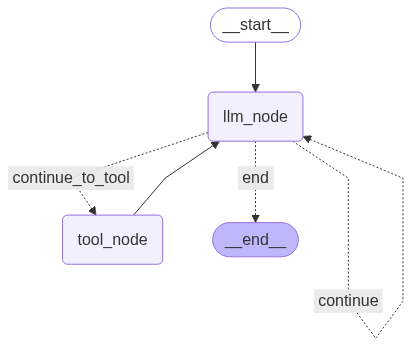

In [58]:
graph

In [59]:
state = graph.get_state(grap_config)

In [ ]:
# state


In [ ]:
with SqliteSaver.from_conn_string("sqlite/checkpoints.db") as checkpointer:
    a = checkpointer.get(grap_config :={"configurable": {"thread_id": "new_thread_id"}})

In [ ]:
from agent_tools.characters import create_character

'Create a new character\n\ninputs\n  character_name (str): Name of character\n  age (int): Age of character\n  gender (str): Gender of character\n  disposition (str) : One-word characteristic describing the characters personality\n  \n  relationships_out (dict[str,str]): Dict containing the outgoing relationships for \n      the characters. That is, how *this* character relates *to* the other. Dict key\n      is name of other character, value is nature of relationship. Example: \n      If creating a character named Victoria, and passing relationships_in =\n          {"Martinques": "Husband", "Evangeline": "Bitter enemy and rival", ...}\n      Means Victoria regards Martiniques as her husband, and Evangeline as her bitter \n      enemy and rival.\n \n  relationships_in: Dict containing the incoming relationship of the character. How\n      the other characters relates to the created character. Example: \n      If creating a character named Victoria and passign relationship_out =\n      

In [ ]:
create_character.

'Tool that can operate on any number of inputs.'

In [5]:
from agent_tools.characters import roster

In [1]:
from importlib import reload
import prompts.playwriter_sysprompt as sysprompt

In [2]:
reload(sysprompt)

<module 'prompts.playwriter_sysprompt' from '/Users/lars/Documents/dev/python/AiStagePlayGen/prompts/playwriter_sysprompt.py'>

In [6]:

print(sysprompt.get_dynamic_playwright_system_message(
    tools=[lambda x : x],
    roster = roster,
    themes= "Loss of innocense, obtaining psychological wholenes, jungian psychology",
    vibe = "weird and funky",
    setting = "Tam Tamoree small town reminiscent of old german village",
    number_of_chapters= 4,
    current_chapter= 1,
    synopsis=None,

))


    You are the co writer of a stage play
    You recieve a story and write the continuation
    As you wil see below, you recieve a header of information about the play, and its current state.
    This information is structured to include: 
     1. The general features of the play such as the themes, vibe, and setting
     2. Scene and Arc description: A list of scenes and the general direction the story should
     move towards in each scene. 
     3. The roster for the current scene, with a small character description for each character.
     4. If not at first chapter you will recieve a small synopsis of the preceding chapters. 
 
    You will recieve the current state of the play with a precursor to a new line for a given role.
    This role will either be the role of the narrator or a character in the play.
    When writing as the narrator you will continue the story by describing the
    unfolding of events based on previous context. When writing for a character you 
    will w

In [ ]:
from agent_tools.characters import get_character_description

In [4]:
from langchain_core.messages import HumanMessage
from agent_graph import StagePlayState
from langchain_core.runnables import RunnableConfig
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from agent_graph import StagePlayWriter


def print_stream(stream):
    for s in stream:
        message = s["context"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini")
# tools = [get_character_description, create_character, human_assistance]

inputs = StagePlayState(
    counter=0,
    context=[
        HumanMessage(
            """Narrator: It is a sunny wistful day in Tam Tamouree,
        Swedenborg and Luna lazily scout over the townspeople from their hidden vantage point atop the old church.
        Luna:
        """
        )
    ],
)

graph_config: RunnableConfig = RunnableConfig({"configurable": {"thread_id": "new_thread_id"}})

playwriter = StagePlayWriter(
    llm=llm,
    themes= """Loss of innocence, Becoming Psychologically whole, Jungian Psychology, Bildung""",
    vibe= """Subtly, Weird and funky""",
    setting= "Tam Tamoree, fictional town in German Bavaria",
    number_of_chapters= 4
)



In [5]:
print_stream(playwriter.graph.stream(input=inputs,stream_mode="values" ,config= graph_config))


================================ Human Message =================================

Narrator: It is a sunny wistful day in Tam Tamouree,
        Swedenborg and Luna lazily scout over the townspeople from their hidden vantage point atop the old church.
        Luna:
        
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_prbNDgplKVtvjQL821rMdFuJ)
 Call ID: call_prbNDgplKVtvjQL821rMdFuJ
  Args:
    query: What does Luna say next?
  human_assistance (call_vkBlVrVqKiAXv2TyT0ln2PmI)
 Call ID: call_vkBlVrVqKiAXv2TyT0ln2PmI
  Args:
    query: What activity are they observing from the church?


In [7]:
snapshot = playwriter.graph.get_state(graph_config)

In [12]:
snapshot.next

('tool_node',)

In [11]:
snapshot.interrupts

(Interrupt(value={'query': 'What does Luna say next?'}, resumable=True, ns=['tool_node:5aa4f5b2-1225-45c2-3c66-2ff81b8af842']),)

In [ ]:
snapshot.

(PregelTask(id='5aa4f5b2-1225-45c2-3c66-2ff81b8af842', name='tool_node', path=('__pregel_pull', 'tool_node'), error=None, interrupts=(Interrupt(value={'query': 'What does Luna say next?'}, resumable=True, ns=['tool_node:5aa4f5b2-1225-45c2-3c66-2ff81b8af842']),), state=None, result=None),)

In [10]:
from langgraph.types import Command

In [17]:
human_response =("Luna: Wow Borgy look at all commotion","Swedenborg and Luna notice the commotion in the marketplace below; a market guard is about to cut of the hand of a theif after an attempted robbery of a pearl necklace")
human_command = Command(resume= {"data": human_response})

In [19]:
print_stream(playwriter.graph.stream(input=human_command,stream_mode="values" ,config= graph_config))

================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_prbNDgplKVtvjQL821rMdFuJ)
 Call ID: call_prbNDgplKVtvjQL821rMdFuJ
  Args:
    query: What does Luna say next?
  human_assistance (call_vkBlVrVqKiAXv2TyT0ln2PmI)
 Call ID: call_vkBlVrVqKiAXv2TyT0ln2PmI
  Args:
    query: What activity are they observing from the church?
================================= Tool Message =================================
Name: human_assistance

["Luna: Wow Borgy look at all commotion", "Swedenborg and Luna notice the commotion in the marketplace below; a market guard is about to cut of the hand of a theif after an attempted robbery of a pearl necklace"]
================================== Ai Message ==================================

Luna: Wow, Borgy, look at all this commotion down there! 

Narrator: As they peer over the edge, their eyes widen in horror at the scene unfolding in the marketplace. A market guard looms over a thief, his sword 

In [ ]:
playwriter.checkpointer.delete_thread("new_thread_id")

In [ ]:
from importlib import reload

import db.handler as db



In [10]:
reload(db)

<module 'db.handler' from '/Users/lars/Documents/dev/python/AiStagePlayGen/db/handler.py'>

In [ ]:
add_entry(character_luna)

Error adding entry: (sqlite3.IntegrityError) UNIQUE constraint failed: character.name
[SQL: INSERT INTO character (name, gender, age, disposition) VALUES (?, ?, ?, ?)]
[parameters: ('Luna', 'F', 16, 'Sassy')]
(Background on this error at: https://sqlalche.me/e/20/gkpj)


In [ ]:
a = get_character("Luna")

In [15]:
db.add_entry(db.luna_relationships)

In [16]:
db.add_entry(db.swedenborg_relationships)

In [17]:
b  = db.get_character_relationships("Luna")

In [18]:
print(b)

In [3]:
from agent_tools.characters import create_character

In [ ]:
create_character.invoke({
    "character_name" : "Rory the Menace",
    "age" : 18,
    "gender" : "M",
    "disposition" : "Hodlum",
    "relationships_out" : {"Luna" : "Secret Crush" ,"Swedenborg" : "Thinks Swedenborg is a wuss",
                         "Captain Flask": "Disregard" },
    "relationships_in" : {"Luna" : "Sees him as a violent thugh" ,"Swedenborg" : "Intimidated",
                         "Captain Flask": "Good for nothin street thug" }
    })

'caracter Rory the Menace created'

In [24]:
import sqlite3 
conn = sqlite3.connect("db/stageplay/state.db")

In [ ]:
from sqlalchemy import create_engine
from sqlalchemy.sql import text

engine = create_engine('sqlite:///db/stageplay/state.db', echo=False)
with engine.connect() as conn:
    try:
        conn.execute(text("CREATE TABLE IF NOT EXISTS test (id INTEGER PRIMARY KEY, name TEXT)"))
        conn.execute(text("INSERT INTO test (name) VALUES ('test')"))
        conn.commit()
        print("Write operation successful. Database is not read-only.")
    except Exception as e:
        print(f"Error: {e}")

Write operation successful. Database is not read-only.


In [8]:
engine = create_engine('sqlite:///db/stageplay/state.db', echo=False)
with engine.connect() as conn:
    try:
        res = conn.execute(text("select * from relationships"))
        # conn.commit()
        print(res.fetchall())
    except Exception as e:
        print(f"Error: {e}")

[(1, 'Luna', 'Swedenborg', 'Aimicable'), (2, 'Luna', 'Captain Flask', 'Veneration and slighthly frightened'), (3, 'Swedenborg', 'Luna', 'Unrequited Infatuation'), (4, 'Swedenborg', 'Captain Flask', 'Veneration'), (5, 'Captain Flask', 'Luna', 'Reminds him of lost youth and daughter that never was'), (6, 'Captain Flask', 'Swedenborg', 'Sees him as a young man with lots of potential'), (7, 'Rory the Menace', 'Luna', 'Secret Crush'), (8, 'Rory the Menace', 'Swedenborg', 'Thinks Swedenborg is a wuss'), (9, 'Rory the Menace', 'Captian Flask', 'Disregard'), (10, 'Rory the Menace', 'Luna', 'Sees him as a violent thugh'), (11, 'Rory the Menace', 'Swedenborg', 'Intimidated'), (12, 'Rory the Menace', 'Captian Flask', 'Good for nothin street thug')]


In [6]:
cursoer = conn.execute(text("SELECT * FROM Relationships"))


ResourceClosedError: This Connection is closed

In [ ]:
kcursoer.fetchall()

[(1, 'Luna', 'Swedenborg', 'Aimicable'),
 (2, 'Luna', 'Captain Flask', 'Veneration and slighthly frightened'),
 (3, 'Swedenborg', 'Luna', 'Unrequited Infatuation'),
 (4, 'Swedenborg', 'Captain Flask', 'Veneration'),
 (5,
  'Captain Flask',
  'Luna',
  'Reminds him of lost youth and daughter that never was'),
 (6,
  'Captain Flask',
  'Swedenborg',
  'Sees him as a young man with lots of potential')]

In [12]:
from sqlalchemy import create_engine, Column, Integer, String 
import db.handler as db
from sqlalchemy.orm import sessionmaker
engine = create_engine('sqlite:///db/stageplay/state.db', echo = False) 
Session = sessionmaker(bind=engine)

In [ ]:
from sqlalchemy.inspection import inspect

In [ ]:
with Session() as session:
    relationship_cols = [i.key for i in inspect(db.Relationships)]
    character_cols = [i.key for i in inspect(db.Character)]
 
    character_query = session.query(db.Character).all()
    
    characters = [{col: getattr(res, col) for col in character_cols} 
                   for res in character_query
                ]
    
    for character in characters:
        relation_query = (session
                          .query(db.Relationships)
                          .filter_by(character = character["name"])
                          .all()
                          )
        character["relationships"] = []
        for relation in relation_query:
            character["relationships"].append(
                {col: getattr(res, col) for col in relationship_cols}
                )
        





[<db.handler.Relationships object at 0x118b5b8a0>, <db.handler.Relationships object at 0x118b5ae00>]
[<db.handler.Relationships object at 0x119df8650>, <db.handler.Relationships object at 0x119e26850>]
[<db.handler.Relationships object at 0x119dbd5e0>, <db.handler.Relationships object at 0x119dbd9a0>]
[<db.handler.Relationships object at 0x119e50750>, <db.handler.Relationships object at 0x119e50bb0>, <db.handler.Relationships object at 0x119ce7ad0>, <db.handler.Relationships object at 0x119cade50>, <db.handler.Relationships object at 0x119cae210>, <db.handler.Relationships object at 0x119cdd440>]


In [45]:
a

{'a': 'b', 'c': None}